In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
class Value:
    def __init__(self, data, _children = (), _op = '', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.grad = 0.0
        self.label = label
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad = out.grad
            other.grad = out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        out =  Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad = out.grad
            other.grad = self.grad
        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        th = math.tanh(x)
        out = Value(th, (self, ), 'tanh')
        return out

In [3]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b; e.label = 'e'
d = e + c
d.label = 'd'
f = Value(-2.0, label='f')
L = d * f
L.label = 'L'
L

Value(data=-8.0)

In [4]:
from graphviz import Digraph


def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in getattr(v, '_prev', []):
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format="svg", graph_attr={"rankdir": "LR"})
    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))
        data_val = getattr(n, 'data', None)
        grad_val = getattr(n, 'grad', 0.0)
        try:
            data_str = f"{float(data_val):.4f}"
        except Exception:
            data_str = str(data_val)

        # Use str() instead of undefined string(), and fix label formatting
        dot.node(name=uid,
                 label="{ %s | data: %s | grad %.4f}" % (n.label, data_str, grad_val),
                 shape="record")

        # If this Value is the result of an operation, draw the op node
        if getattr(n, '_op', ''):
            op_node = uid + n._op
            dot.node(name=op_node, label=n._op)
            dot.edge(op_node, uid)

    # Connect children to the op node that produced their parent
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + getattr(n2, '_op', ''))

    return dot

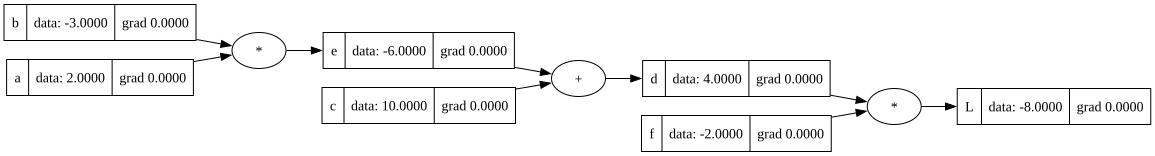

In [5]:
draw_dot(L)

In [6]:
L.grad = 1.0
d.grad = -2.0
f.grad = 4.0
e.grad = -2.0
c.grad = -2.0
a.grad = -2.0 * -3.0
b.grad = -2.0 * 2.0

In [7]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b; e.label = 'e'
d = e + c
d.label = 'd'
L = d * f
L.label = 'L'
L
print(L.data)

-7.286496


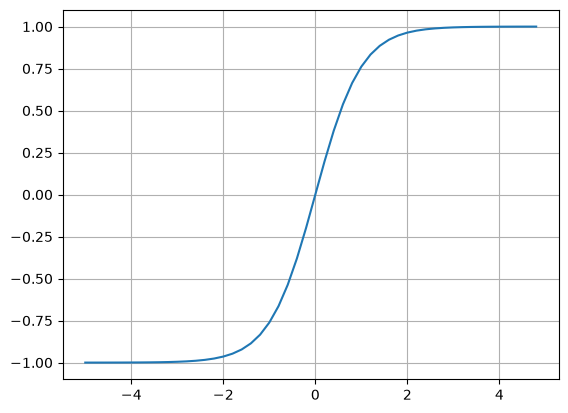

In [8]:
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2))); plt.grid();

In [9]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b')
x1w1 = x1 * w1; x1w1.label='x1w1'
x2w2 = x2 * w2; x2w2.label='x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label="x1w1 + x2w2"
n = x1w1x2w2 + b; n.label='n'
o = n.tanh(); o.label='o'

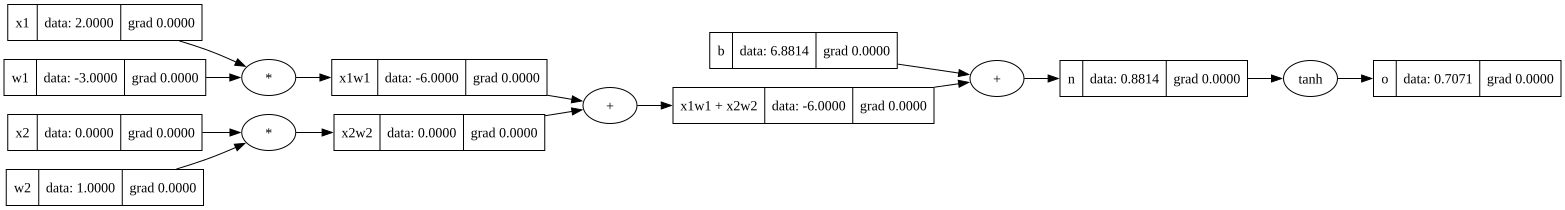

In [10]:
draw_dot(o)

In [11]:
o.grad = 1
n.grad = 0.5
b.grad = 0.5
x1w1x2w2.grad = 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5
x1.grad = 0.5 * -3.0
w1.grad = 0.5 * 2.0
x2.grad = 0.5 * 1.0
w2.grad = 0.5 * 0.0